In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
train_df = pd.read_csv("../data/raw/train.csv")
train_df.head()

,row_id,body,rule,subreddit,positive_example_1,positive_example_2,negative_example_1,negative_example_2,rule_violation
0,0,Banks don't want you to know this! Click here ...,"No Advertising: Spam, referral links, unsolici...",Futurology,If you could tell your younger self something ...,hunt for lady for jack off in neighbourhood ht...,Watch Golden Globe Awards 2017 Live Online in ...,"DOUBLE CEE x BANDS EPPS - ""BIRDS""\n\nDOWNLOAD/...",0
1,1,SD Stream [ ENG Link 1] (http://www.sportsstre...,"No Advertising: Spam, referral links, unsolici...",soccerstreams,[I wanna kiss you all over! Stunning!](http://...,LOLGA.COM is One of the First Professional Onl...,#Rapper \n🚨Straight Outta Cross Keys SC 🚨YouTu...,[15 Amazing Hidden Features Of Google Search Y...,0
2,2,Lol. Try appealing the ban and say you won't d...,No legal advice: Do not offer or request legal...,pcmasterrace,Don't break up with him or call the cops. If ...,It'll be dismissed: https://en.wikipedia.org/w...,Where is there a site that still works where y...,Because this statement of his is true. It isn'...,1
3,3,she will come your home open her legs with an...,"No Advertising: Spam, referral links, unsolici...",sex,Selling Tyrande codes for 3€ to paypal. PM. \n...,tight pussy watch for your cock get her at thi...,NSFW(obviously) http://spankbang.com/iy3u/vide...,Good News ::Download WhatsApp 2.16.230 APK for...,1
4,4,code free tyrande --->>> [Imgur](http://i.imgu...,"No Advertising: Spam, referral links, unsolici...",hearthstone,wow!! amazing reminds me of the old days.Well...,seek for lady for sex in around http://p77.pl/...,must be watch movie https://sites.google.com/s...,We're streaming Pokemon Veitnamese Crystal RIG...,1


In [4]:
train_df.count()

row_id                2029
body                  2029
rule                  2029
subreddit             2029
positive_example_1    2029
positive_example_2    2029
negative_example_1    2029
negative_example_2    2029
rule_violation        2029
dtype: int64

In [8]:
train_df['rule'].value_counts()

rule
No legal advice: Do not offer or request legal advice.                                                     1017
No Advertising: Spam, referral links, unsolicited advertising, and promotional content are not allowed.    1012
Name: count, dtype: int64

In [10]:
train_df.notnull().count()

row_id                2029
body                  2029
rule                  2029
subreddit             2029
positive_example_1    2029
positive_example_2    2029
negative_example_1    2029
negative_example_2    2029
rule_violation        2029
dtype: int64

In [3]:
# Load test data
test_df = pd.read_csv("../data/raw/test.csv")

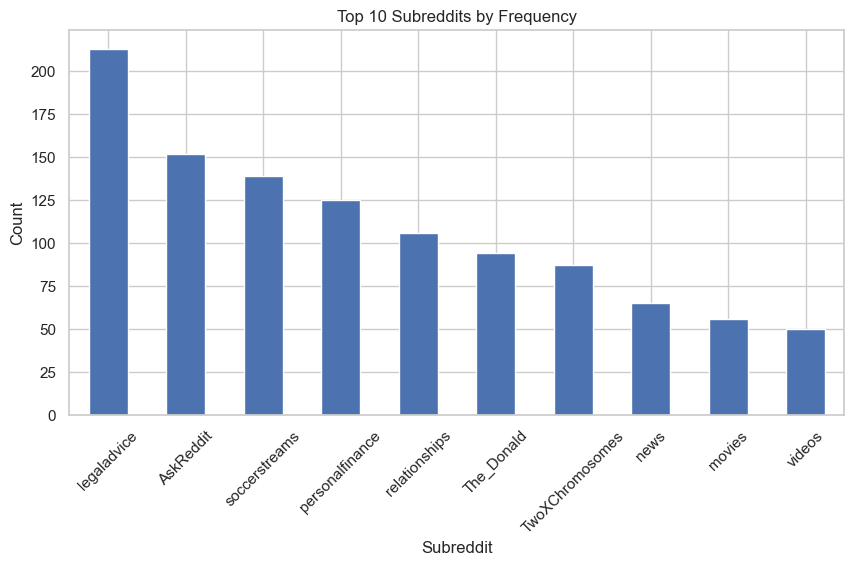

In [4]:
plt.figure(figsize=(10,5))

train_df["subreddit"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Subreddits by Frequency")
plt.xlabel("Subreddit")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [6]:
num_subreddits = train_df["subreddit"].nunique()
print("Number of unique subreddits:", num_subreddits)

Number of unique subreddits: 100


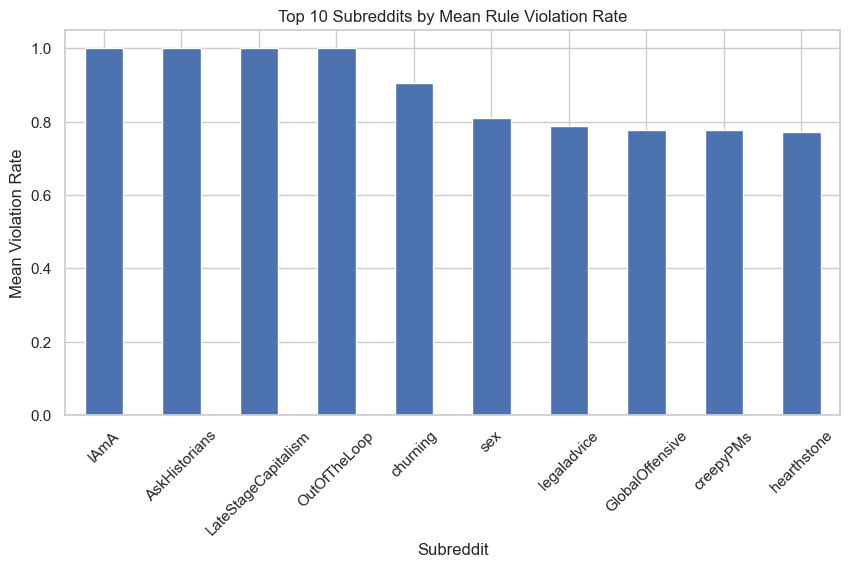

In [9]:
plt.figure(figsize=(10,5))

violation_rate = (
    train_df.groupby("subreddit")["rule_violation"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

violation_rate.plot(kind="bar")

plt.title("Top 10 Subreddits by Mean Rule Violation Rate")
plt.ylabel("Mean Violation Rate")
plt.xlabel("Subreddit")
plt.xticks(rotation=45)
plt.show()

/var/folders/32/tfpg9gbn7b199xmg_qg4r49c0000gn/T/ipykernel_69766/1858184825.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

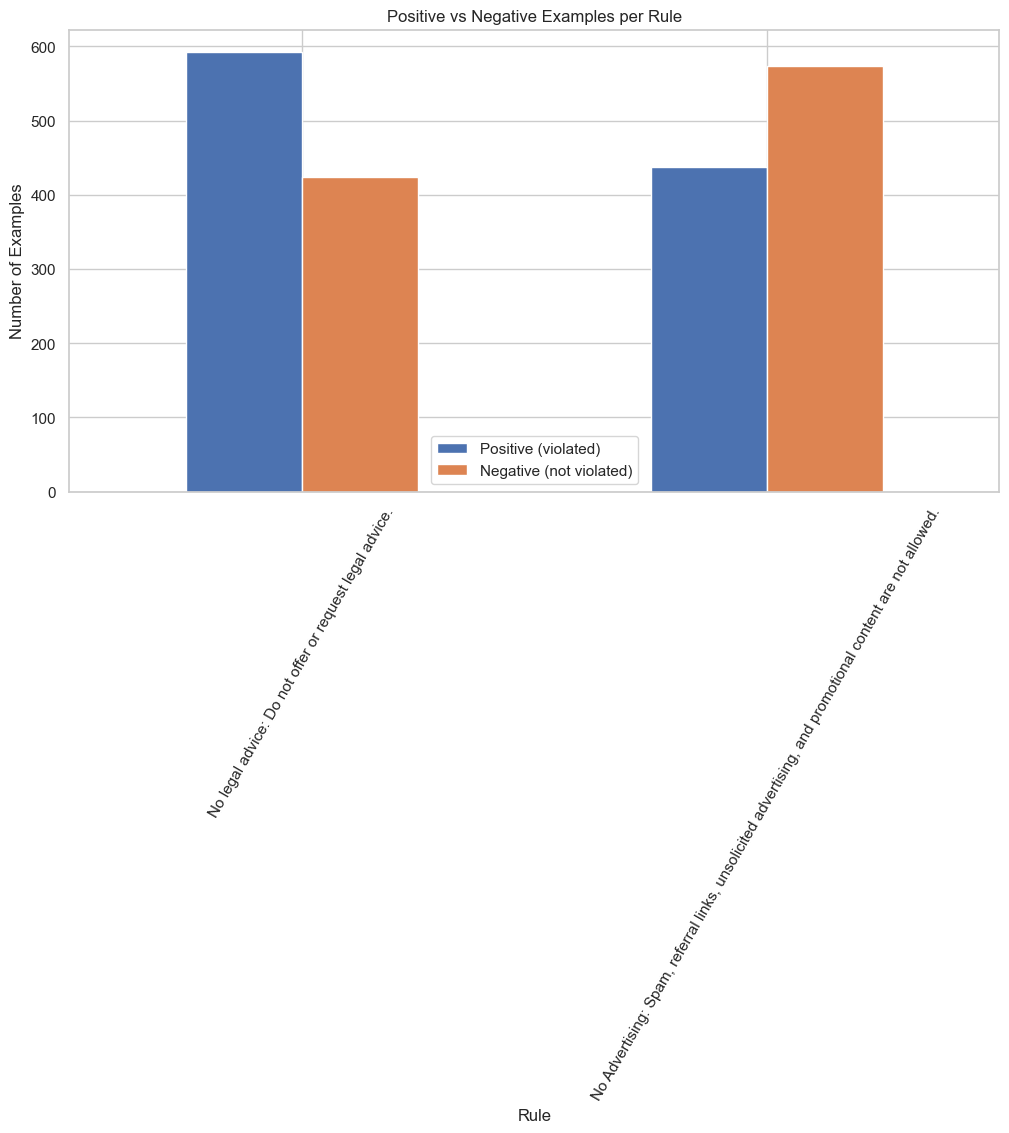

In [ ]:
# Count positives and negatives for each rule
rule_counts = (
    train_df.groupby(["rule", "rule_violation"])
    .size()
    .reset_index(name="count")
    .pivot(index="rule", columns="rule_violation", values="count")
    .fillna(0)
)

rule_counts.columns = ["negative_examples", "positive_examples"]

# Sort by total examples and take top 15 rules
rule_counts["total"] = rule_counts.sum(axis=1)
top_rules = rule_counts.sort_values("total", ascending=False).head(15)

# Plot
plt.figure(figsize=(12,6))
top_rules[["positive_examples", "negative_examples"]].plot(
    kind="bar",
    stacked=False,
    figsize=(12,6)
)

plt.title("Positive vs Negative Examples per Rule")
plt.xlabel("Rule")
plt.ylabel("Number of Examples")
plt.xticks(rotation=60)
plt.legend(["Positive (violated)", "Negative (not violated)"])
plt.tight_layout()
plt.show()